In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 5.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pyplot import rcParams
rcParams['figure.figsize'] = 15, 6
from datetime import datetime
from pmdarima.arima import auto_arima

In [ ]:
dataparse = lambda dates: datetime.strptime(dates, '%Y-%m')
data = pd.read_csv(
    'AirPassengers.csv',
    parse_dates=['Month'],
    index_col='Month',
    date_parser=dataparse
)

/tmp/ipykernel_4086/2769871700.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = pd.read_csv(


In [ ]:
data

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


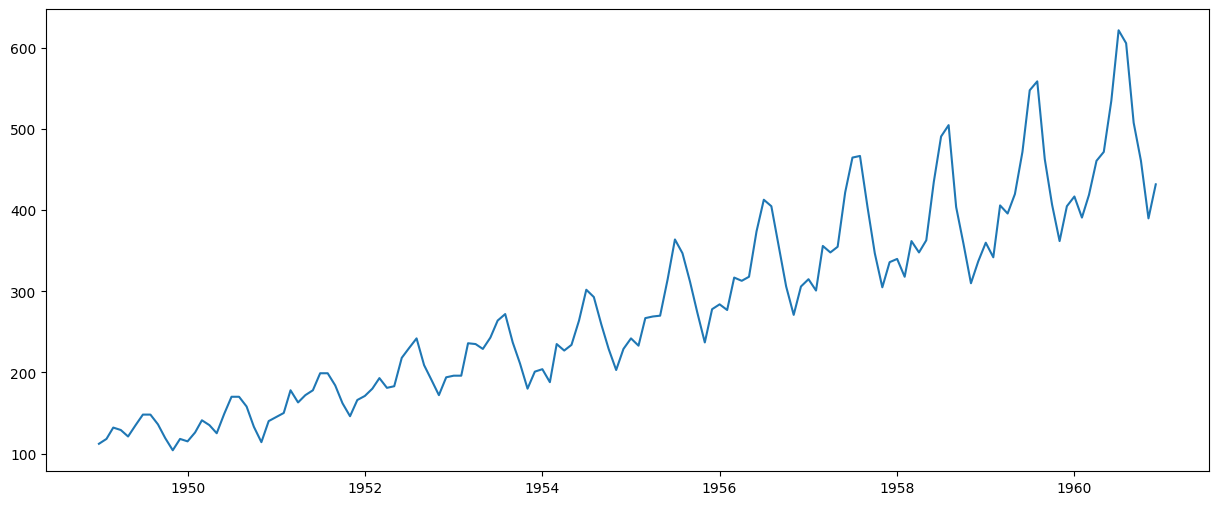

In [ ]:
plt.plot(data)

In [ ]:
stepwise_model = auto_arima(
    data,
    start_p=1,
    start_q=1,
    start_d=0,
    start_P=0,
    max_p=6,
    max_q=6,
    m=12,
    seasonal=True,
    trace=True,
    stepwise=False
)

 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.03 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1030.752, Time=0.13 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=1032.276, Time=0.41 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1030.408, Time=0.09 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=1032.128, Time=0.27 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=1034.096, Time=0.73 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.23 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=2.18 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=inf, Time=4.61 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1020.639, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.19 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1019.494, Time=0.61 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.17 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1020.327, Time=0.51 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=1012.991, Time=2.61 sec
 ARIM

In [ ]:
print(stepwise_model.aic())

1012.9907965020693


In [ ]:
train = data.loc['1949-01-01': '1959-12-01']
test = data.loc['1960-01-01':]

In [ ]:
train

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1959-08-01,559
1959-09-01,463
1959-10-01,407


In [ ]:
test

,#Passengers
Month,
1960-01-01,417
1960-02-01,391
1960-03-01,419
1960-04-01,461
1960-05-01,472
1960-06-01,535
1960-07-01,622
1960-08-01,606
1960-09-01,508


In [ ]:
stepwise_model.fit(train)

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(1, 1, 2, 12),
      suppress_warnings=True, with_intercept=False)

In [ ]:
future_forecast = stepwise_model.predict(n_periods=12)

In [ ]:
future_forecast

,0
1960-01-01,420.225053
1960-02-01,398.443931
1960-03-01,461.899012
1960-04-01,450.680910
1960-05-01,473.998644
1960-06-01,537.901617
1960-07-01,612.220484
1960-08-01,623.571807
1960-09-01,520.158221
1960-10-01,462.311002


In [ ]:
future_forecast = pd.DataFrame(future_forecast, index=test.index, columns=['#Passengers'])

<Axes: xlabel='Month'>

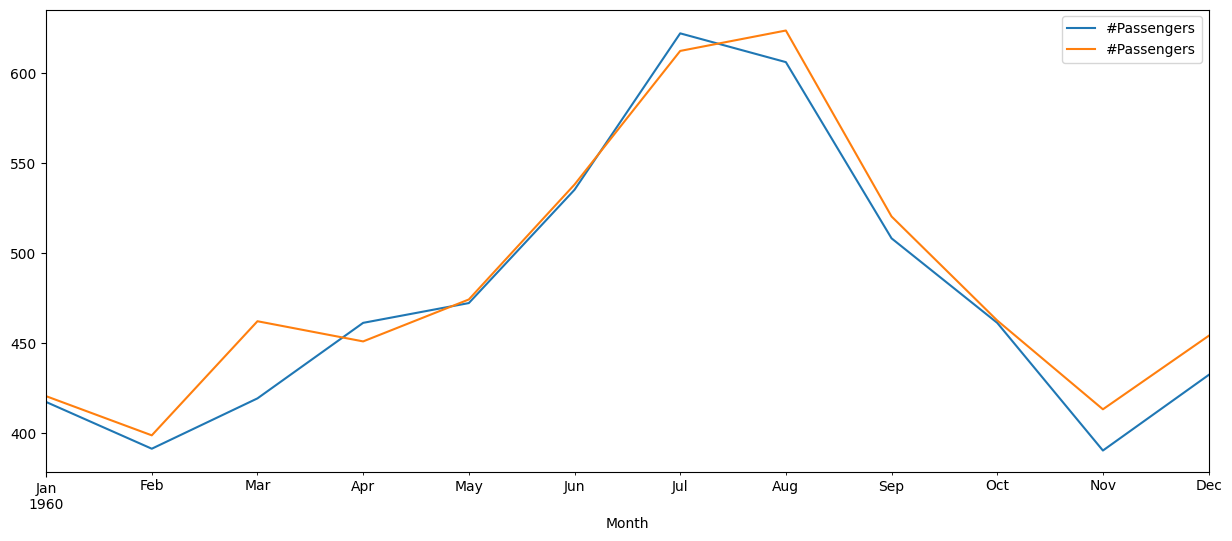

In [ ]:
pd.concat([test, future_forecast], axis=1).plot()

<Axes: xlabel='Month'>

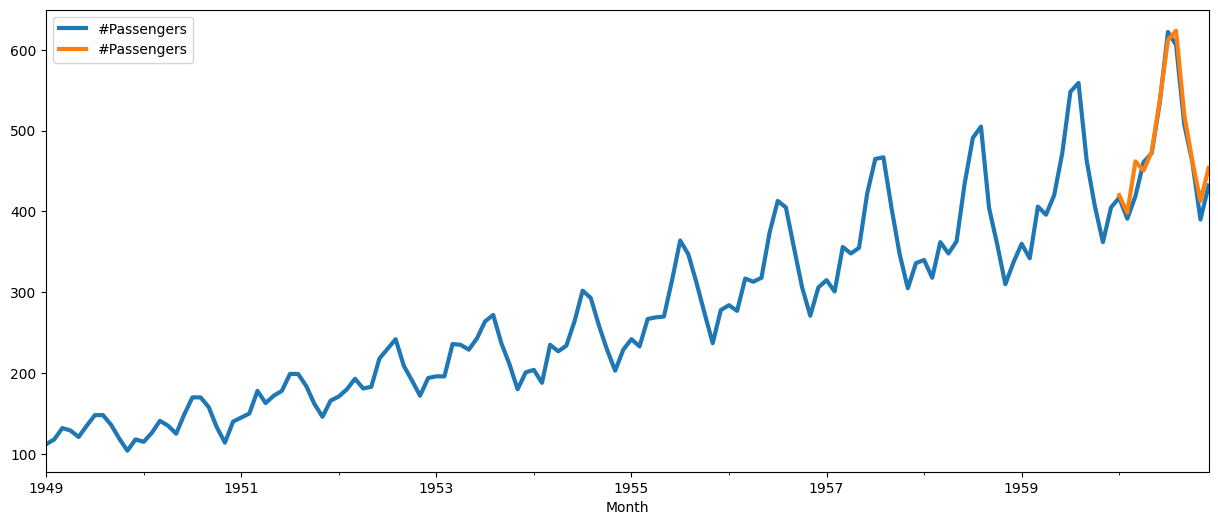

In [ ]:
pd.concat([data, future_forecast], axis=1).plot(linewidth=3)